Модель нейронов места.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats.qmc import Sobol, PoissonDisk
# for normal distribution pdf
from scipy.stats import norm

# from scipy.spatial import Voronoi

# for plotting circles
from matplotlib.collections import PatchCollection

from sklearn.metrics import pairwise_distances

In [2]:
from model import PlaceCellsModel

In [3]:
from ripser import Rips

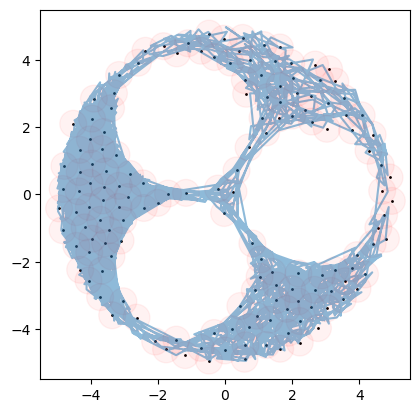

In [66]:
m = PlaceCellsModel(n_holes=3, move_time_frac=0.99, n_cells=1024, cell_radius=0.04, sigma_activation=1.)

geo = m.geometry

traj = m.sample_Levy_walk(n_steps=2_000, min_step=0.3, max_step=5., exponent=1.5)

points = m.cells

fig, ax = plt.subplots()

_ = ax.scatter(points[:,0], points[:,1], c='black', s=1.)

circles = [plt.Circle((xi, yi), radius=0.04*10, fill=True, alpha=0.05, color='red') for xi, yi in points]

collection = PatchCollection(circles, match_original=True)
ax.add_collection(collection)

offset = 0.5

_ = ax.set(aspect='equal', 
           xlim=[-5-offset, 5+offset], ylim=[-5-offset, 5+offset])
          #,xlabel=r'$x_1$', ylabel=r'$x_2$',)

_ = ax.plot(traj[:,0], traj[:,1], alpha=0.5)

plt.show()

In [67]:
m.n_cells

151

Text(0, 0.5, 'time')

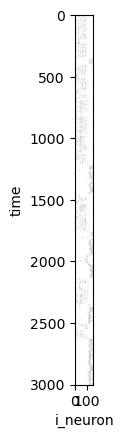

In [68]:
s = m.sample_signal(n_steps=3_000)

plt.imshow(1-s, cmap='gray')

plt.xlabel('i_neuron')
plt.ylabel('time')

In [69]:
s += np.random.normal(size=s.shape, loc=0, scale=0.01)

In [70]:
s = s/np.linalg.norm(s,axis=1)[:,np.newaxis]

In [92]:
"""Demo for topology-regularised autoencoders.

This example demonstrates how to use `pytorch-topological` to create an
additional differentiable loss term that makes autoencoders aware of
topological features. See [Moor20a]_ for more information.
"""

import torch
import torch.optim as optim

import matplotlib.pyplot as plt

from tqdm import tqdm

from torch.utils.data import DataLoader

from torch_topological.datasets import Spheres

from torch_topological.nn import SignatureLoss
from torch_topological.nn import VietorisRipsComplex


class LinearAutoencoder(torch.nn.Module):
    """Simple linear autoencoder class.

    This module performs simple embeddings based on an MSE loss. This is
    similar to ordinary principal component analysis. Notice that the
    class is only meant to provide a simple example that can be run
    easily even without the availability of a GPU. In practice, there
    are many more architectures with improved expressive power
    available.
    """

    def __init__(self, input_dim, latent_dim=2):
        """Create new autoencoder with pre-defined latent dimension."""
        super().__init__()

        self.input_dim = input_dim
        self.latent_dim = latent_dim

        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(self.input_dim, 100),
            torch.nn.ReLU(),
            torch.nn.Linear(100, 50),
            torch.nn.ReLU(),
            torch.nn.Linear(50, self.latent_dim)
        )

        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(self.latent_dim, 50),
            torch.nn.ReLU(),
            torch.nn.Linear(50, 100),
            torch.nn.ReLU(),
            torch.nn.Linear(100, self.input_dim)
        )

        self.loss_fn = torch.nn.MSELoss()

    def encode(self, x):
        """Embed data in latent space."""
        return self.encoder(x)

    def decode(self, z):
        """Decode data from latent space."""
        return self.decoder(z)

    def forward(self, x):
        """Embeds and reconstructs data, returning a loss."""
        z = self.encode(x)
        x_hat = self.decode(z)

        # The loss can of course be changed. If this is your first time
        # working with autoencoders, a good exercise would be to 'grok'
        # the meaning of different losses.
        reconstruction_error = self.loss_fn(x, x_hat)
        return reconstruction_error


class TopologicalAutoencoder(torch.nn.Module):
    """Wrapper for a topologically-regularised autoencoder.

    This class uses another autoencoder model and imbues it with an
    additional topology-based loss term.
    """
    def __init__(self, model, lam=10.0):
        super().__init__()

        self.lam = lam
        self.model = model
        self.loss = SignatureLoss(p=2)

        # TODO: Make dimensionality configurable
        self.vr = VietorisRipsComplex(dim=1)

    def forward(self, x):
        z = self.model.encode(x)

        pi_x = [self.vr(x)[1]]
        pi_z = [self.vr(z)[1]]

        geom_loss = self.model(x)
        topo_loss = self.loss([x, pi_x], [z, pi_z])

        loss = geom_loss + self.lam * topo_loss
        return loss

In [93]:
data_set = torch.tensor(s).to(torch.float32)

train_loader = DataLoader(
        data_set,
        batch_size=256,
        shuffle=True,
        drop_last=True
    )

    # Let's set up the two models that we are training. Note that in
    # a real application, you would have a more complicated training
    # setup, potentially with early stopping etc. This training loop
    # is merely to be seen as a proof of concept.
model = LinearAutoencoder(input_dim=data_set.shape[1])
topo_model = TopologicalAutoencoder(model, lam=100)

optimizer = optim.Adam(topo_model.parameters(), lr=1e-3)

n_epochs = 5

progress = tqdm(range(n_epochs))



for i in progress:
    topo_model.train()

    for batch, x in enumerate(train_loader):
        loss = topo_model(x)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    progress.set_postfix(loss=loss.item())

100%|███████████████████████████████████| 5/5 [00:02<00:00,  2.35it/s, loss=109]


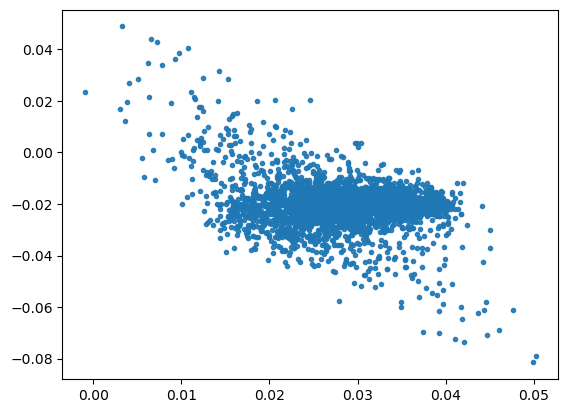

In [94]:
test_loader = DataLoader(
            data_set,
            shuffle=False,
            batch_size=len(data_set)
    )

X = next(iter(test_loader))
Z = topo_model.model.encode(X).detach().numpy()

plt.scatter(
    Z[:, 0], Z[:, 1],
    cmap='Set1',
    marker='.',
    alpha=0.9,
)
plt.show()